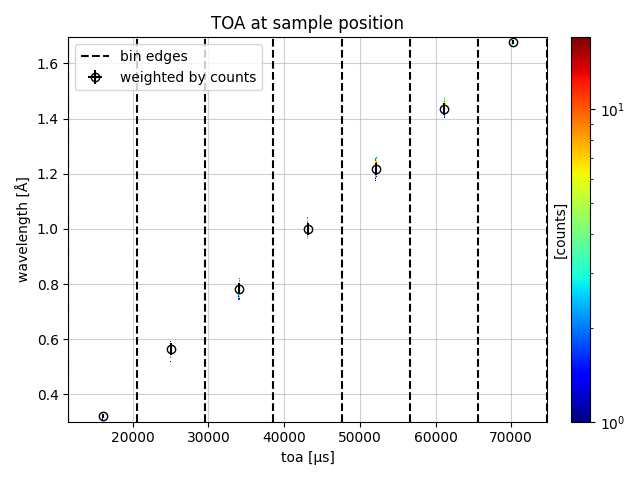

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
from trex.instrument import Instrument
from trex.utils import centers_to_edges

central_wavelength = 1 * sc.Unit("Å")
mode = "High Flux"  # Chopper mode
rrm = 8
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
res = trex.model.run()




fig, ax = plt.subplots()
# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["Sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]
# Histogram and plot
toa_sample = events_at_sample.hist(wavelength=800, toa=1000).plot(
    norm="log", cbar=True, ax=ax, cmap="jet", title="TOA at sample position"
)

toa_min, toa_max = trex.calculate_toa_range_at("Sample")
toa_centers = sc.array(
    dims=["toa"], values=((toa_min + toa_max).to(unit="us") / 2).values, unit="us"
)
toa_bin_edges = centers_to_edges(toa_centers)  # dim='toa')
for edge in toa_bin_edges:
    vline = ax.axvline(x=edge.values, c="k", linestyle="--", label="bin edges")


toa_binned = events_at_sample.bin(toa=toa_bin_edges)
# Weighted mean of wavelength inside each bin
wavelength_mu = (
    toa_binned.bins.data * toa_binned.bins.coords["wavelength"]
).bins.sum() / toa_binned.bins.sum()

# Variance of wavelengths inside each bin
wavelength_var = (
    toa_binned.bins.data * (toa_binned.bins.coords["wavelength"] - wavelength_mu) ** 2
) / toa_binned.bins.sum()

# TOA mean of wavelength inside each bin
toa_mu = (
    toa_binned.bins.data * toa_binned.bins.coords["toa"]
).bins.sum() / toa_binned.bins.sum()

# Variance of TOA inside each bin
toa_var = (
    toa_binned.bins.data * (toa_binned.bins.coords["toa"] - toa_mu) ** 2
) / toa_binned.bins.sum()

ebplot = ax.errorbar(
    x=toa_mu.values,
    xerr=sc.sqrt(toa_var.hist()).values,
    y=wavelength_mu.values,
    yerr=sc.sqrt(wavelength_var.hist()).values,
    fmt="ok",
    linestyle="",
    mfc="none",
    label="weighted by counts",
)
ax.grid(alpha=0.6)
ax.set_xlim((toa_bin_edges.min().values, toa_bin_edges.max().values))
ax.legend(handles=[vline, ebplot])
fig.tight_layout()
plt.show()

In [13]:
import plopp as pp
toa_m3 = trex.calculate_toa_at("Monitor 3")
toa_m3_edge = centers_to_edges(toa_m3).rename_dims({'time':'toa'}).to(unit='us')
toa_det = trex.calculate_toa_at("Detector")
toa_det_edge = centers_to_edges(toa_det).rename_dims({'time':'toa'}).to(unit='us')

toa_bin_plot = sc.linspace("toa", toa_m3_edge.min(), toa_det_edge.max(), num=3000, unit="us")
hist_m3 = res.detectors["Monitor 3"].toa.data.hist(toa=toa_bin_plot)
hist_det = res.detectors["Detector"].toa.data.hist(toa=toa_bin_plot)

pp.plot({"Monitor 3": hist_m3, "Detector": hist_det}, grid=True)  # type: ignore

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [ ]:
# hist_m3_binned=hist_m3.bin(toa=toa_bin_edges)
# (hist_m3_binned.bins.data*hist_m3.bins.coords['toa']).bins.sum()
hist_m3

<scipp.DataArray>
Dimensions: Sizes[toa:2999, ]
Coordinates:
* toa                       float64            [µs]  (toa [bin-edge])  [11459.8, 11481.3, ..., 76065.8, 76087.3]
Data:
                            float64         [counts]  (toa)  [0, 0, ..., 0, 0]

In [ ]:
res.detectors["Monitor 3"].toa.data.hist(toa=toa_bin_plot)
toa_bin_plot
toa_m3_edge

wavelength_mu = (
    toa_binned.bins.data * toa_binned.bins.coords["wavelength"]
).bins.sum() / toa_binned.bins.sum()

<scipp.Variable> (toa: 8)    float64            [µs]  [11459.8, 20462.3, ..., 65443.8, 74446.9]

In [16]:
toa_m3_cen = res.detectors["Monitor 3"].toa.data.hist(toa=toa_m3_edge)
toa_det_cen = res.detectors["Detector"].toa.data.hist(toa=toa_det_edge)
toa_m3_cen

<scipp.DataArray>
Dimensions: Sizes[toa:7, ]
Coordinates:
* toa                       float64            [µs]  (toa [bin-edge])  [11459.8, 20462.3, ..., 65443.8, 74446.9]
Data:
                            float64         [counts]  (toa)  [148, 328, ..., 679, 200]